In [1]:
%load_ext autoreload
%autoreload 2

## Calculate agreement for annotations done using Rotten Reviews paper's guidelines

In [ ]:
# Load TSVs to get scores
import pandas as pd
import os

# Make sure to run this notebook from the root of the repository, so that the relative paths to the data files are correct.
HOME = None # Add path to the repository root
DATA_PATH = os.path.join(HOME, "rqe_data")

aone_df_scores = pd.read_csv(os.path.join(DATA_PATH, "human_eval/annotation_rottenreviews_aone.tsv"), sep="\t")
atwo_df_scores = pd.read_csv(os.path.join(DATA_PATH, "human_eval/annotation_rottenreviews_atwo.tsv"), sep="\t")
rottenreviews_human_df_scores = pd.read_csv(os.path.join(DATA_PATH, "human_eval/annotation_rottenreviews_rottenreviews_human.tsv"), sep="\t")

In [8]:
# Create maps for metrics which have words instead of scores
numeric_score_mapper = {
    "Factuality": {
        "factual": 3,
        "partially factual": 2,
        "unfactual": 1
        },
    "Sentiment_Polarity": {
        "positive": 3,
        "neutral": 2,
        "negative": 1
        },
    "Politeness": {
        "polite": 3,
        "neutral": 2,
        "impolite": 1
        },
    "Vagueness": {
        "none": 5,
        "low": 4,
        "moderate": 3,
        "high": 2,
        "extreme": 1
        }
    }

value_range = {
    'Comprehensiveness': range(0, 6),
    'Usage_of_Technical_Terms': range(0, 6),
    'Factuality': range(1, 4),
    'Sentiment_Polarity': range(1, 4),
    'Politeness': range(1, 4),
    'Vagueness': range(1, 6),
    'Objectivity': range(0, 6),
    'Fairness': range(0, 6),
    'Actionability': range(0, 6),
    'Constructiveness': range(0, 6),
    'Relevance_Alignment': range(0, 6),
    'Clarity_and_Readability': range(0, 6),
    'Overall_Quality': range(0, 101)
}

from scipy.stats import spearmanr
from collections import defaultdict


considered_metrics = list(value_range.keys())

# Parse scores
sampled_rottenreviews_human_scores = defaultdict(list)
sampled_aone_scores = defaultdict(list)
sampled_atwo_scores = defaultdict(list)
for review_id in aone_df_scores['reviewID'].tolist():
    for metric in considered_metrics:
        if metric in numeric_score_mapper:
            sampled_rottenreviews_human_scores[metric].append(int(numeric_score_mapper[metric][rottenreviews_human_df_scores[rottenreviews_human_df_scores['reviewID'] == review_id][metric.replace("_", " ")].values[0]]))
            sampled_aone_scores[metric].append(int(numeric_score_mapper[metric][aone_df_scores[aone_df_scores['reviewID'] == review_id][metric.replace("_", " ")].values[0]]))
            sampled_atwo_scores[metric].append(int(numeric_score_mapper[metric][atwo_df_scores[atwo_df_scores['reviewID'] == review_id][metric.replace("_", " ")].values[0]]))
        elif metric == "Overall_Quality":
            sampled_rottenreviews_human_scores[metric].append(int(rottenreviews_human_df_scores[rottenreviews_human_df_scores['reviewID'] == review_id][metric.replace("_", " ")].values[0]))
            sampled_aone_scores[metric].append(int(aone_df_scores[aone_df_scores['reviewID'] == review_id][metric.replace("_", " ")].values[0]))
            sampled_atwo_scores[metric].append(int(atwo_df_scores[atwo_df_scores['reviewID'] == review_id][metric.replace("_", " ")].values[0]))
        else:
            sampled_rottenreviews_human_scores[metric].append(int(rottenreviews_human_df_scores[rottenreviews_human_df_scores['reviewID'] == review_id][metric.replace("_", " ")].values[0][0]))
            sampled_aone_scores[metric].append(int(aone_df_scores[aone_df_scores['reviewID'] == review_id][metric.replace("_", " ")].values[0][0]))
            sampled_atwo_scores[metric].append(int(atwo_df_scores[atwo_df_scores['reviewID'] == review_id][metric.replace("_", " ")].values[0][0]))


#### Agreement for 30 reviews

In [ ]:
# Calculate agreement for each metric considered in RottenReviews paper between all the annotators.
import krippendorff
import numpy as np

for metric in considered_metrics:
    print(f"Metric: {metric}")
    
    print("Krippendorff's alpha between Annotator 1 and 2:", krippendorff.alpha(reliability_data=np.array([sampled_aone_scores[metric], sampled_atwo_scores[metric]]), level_of_measurement='interval', value_domain=value_range[metric]))
    print("Krippendorff's alpha between Annotator 1 and Human annotations from Rotten Reviews paper:", krippendorff.alpha(reliability_data=np.array([sampled_aone_scores[metric], sampled_rottenreviews_human_scores[metric]]), level_of_measurement='interval', value_domain=value_range[metric]))
    print("Krippendorff's alpha between Annotator 2 and Human annotations from Rotten Reviews paper:", krippendorff.alpha(reliability_data=np.array([sampled_atwo_scores[metric], sampled_rottenreviews_human_scores[metric]]), level_of_measurement='interval', value_domain=value_range[metric]))
    print("Overall Krippendorff's alpha:", krippendorff.alpha(reliability_data=np.array([sampled_aone_scores[metric], sampled_atwo_scores[metric], sampled_rottenreviews_human_scores[metric]]), level_of_measurement='interval', value_domain=value_range[metric]))

    print()

Metric: Comprehensiveness
Krippendorff's alpha between Annotator 1 and 2: -0.21637068789548874
Krippendorff's alpha between Annotator 1 and Human annotations from Rotten Reviews paper: 0.07086614173228345
Krippendorff's alpha between Annotator 2 and Human annotations from Rotten Reviews paper: 0.5394107277763787
Overall Krippendorff's alpha: 0.17941480854266645

Metric: Usage_of_Technical_Terms
Krippendorff's alpha between Annotator 1 and 2: -0.5407643312101911
Krippendorff's alpha between Annotator 1 and Human annotations from Rotten Reviews paper: -0.03964757709251088
Krippendorff's alpha between Annotator 2 and Human annotations from Rotten Reviews paper: -0.07598784194528885
Overall Krippendorff's alpha: -0.11812693751019743

Metric: Factuality
Krippendorff's alpha between Annotator 1 and 2: 0.0
Krippendorff's alpha between Annotator 1 and Human annotations from Rotten Reviews paper: -0.09728183118741063
Krippendorff's alpha between Annotator 2 and Human annotations from Rotten Rev

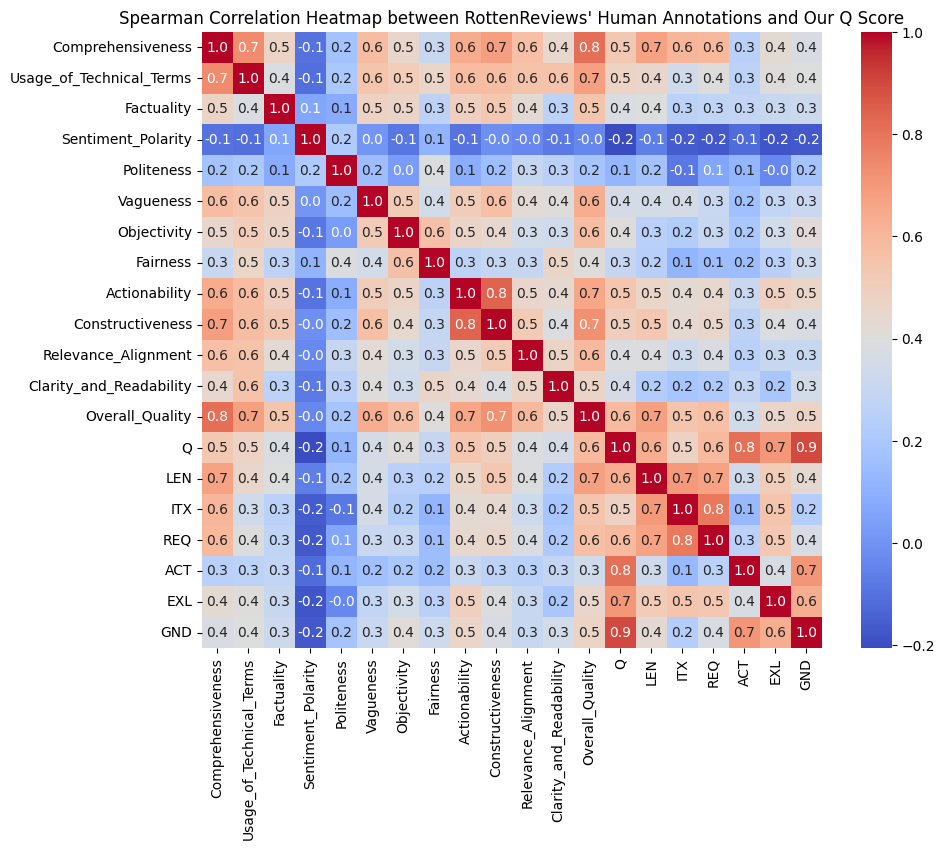

In [ ]:
# Calculate correlation between our Q score and all their metrics + overall quality for 100 reviews
# Make SNS heatmap
import seaborn as sns
import matplotlib.pyplot as plt
import json

# Load our automatic measurements for the reviews being considered.
with open(os.path.join(DATA_PATH, "human_eval/rottenreviews_our_automatic_metrics.json"), "r") as f:
    rottenreviews_our_automatic_metrics = json.load(f)

with open(os.path.join(DATA_PATH, "human_eval/rottenreviews_human_annotations.json"), "r") as f:
    rottenreviews_annotations = json.load(f)

all_scores = defaultdict(list)

# Iterate over all 100 reviews
for review_id in rottenreviews_our_automatic_metrics.keys():
    for metric in considered_metrics:
        if metric in numeric_score_mapper:
            all_scores[metric].append(numeric_score_mapper[metric][rottenreviews_annotations[review_id]['annotatedMetrics'][metric]])
        else:
            all_scores[metric].append(rottenreviews_annotations[review_id]['annotatedMetrics'][metric])
    all_scores['Q'].append(rottenreviews_our_automatic_metrics[review_id]['metrics']['Q'])
    for our_metric in ["LEN", "ITX", "REQ", "ACT", "EXL", "GND"]:
        all_scores[our_metric].append(rottenreviews_our_automatic_metrics[review_id]['metrics'][our_metric])

assert len(all_scores['Q']) == len(all_scores[considered_metrics[0]]), "Mismatch in number of scores"

all_scores_df = pd.DataFrame(all_scores)
corr = all_scores_df.corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".1f")
plt.title("Spearman Correlation Heatmap between RottenReviews' Human Annotations and Our Q Score")
plt.show()

## Agreement and correlation with our guidelines

In [ ]:
import pandas as pd
import random

# 30 reviews annotated by 3 humans using the refined guidelines
aone_refined_df_scores = pd.read_csv(os.path.join(DATA_PATH, "human_eval/annotation_refined_guidelines_aone.tsv"), sep="\t")
atwo_refined_df_scores = pd.read_csv(os.path.join(DATA_PATH, "human_eval/annotation_refined_guidelines_atwo.tsv"), sep="\t")
athree_refined_df_scores = pd.read_csv(os.path.join(DATA_PATH, "human_eval/annotation_refined_guidelines_athree.tsv"), sep="\t")

# Singly annotated 70 reviews
remaining_df_scores = pd.read_csv(os.path.join(DATA_PATH, "human_eval/annotation_refined_guidelines_remaining_reviews.tsv"), sep="\t")

assert len(aone_refined_df_scores) == len(atwo_refined_df_scores) == len(athree_refined_df_scores) == 30
assert len(remaining_df_scores) == 70

#### Agreement for 30 reviews

In [17]:
def qwa(aspect, scoreX, ScoreY):
    if aspect == "Stance":
        dmin = 1
        dmax = 4
    else:
        dmin = 1
        dmax = 5
    delta = dmax - dmin
    return sum([max(0, 1 - ((sx - sy) / delta)**2) for sx, sy in zip(scoreX, ScoreY)])/len(scoreX)

In [20]:
# Calculate agreement on 30 reviews between three annotators

from sklearn.metrics import cohen_kappa_score
from scipy.stats import spearmanr
import numpy as np
import krippendorff

aspects = ["Substantiveness", "Actionability", "Grounding", "Stance", "Objectivity", "Readability"]

for aspect in aspects:
    aone_scores = [int(aone_refined_df_score[0]) for aone_refined_df_score in aone_refined_df_scores[aspect]]
    atwo_scores = [int(atwo_refined_df_score[0]) for atwo_refined_df_score in atwo_refined_df_scores[aspect]]
    athree_scores = [int(athree_refined_df_score[0]) for athree_refined_df_score in athree_refined_df_scores[aspect]]

    print(f"Aspect: {aspect}")
    if aspect in ["Substantiveness", "Actionability", "Grounding"]:
        alpha = krippendorff.alpha(reliability_data=np.array([aone_scores, atwo_scores, athree_scores]), level_of_measurement='interval', value_domain=range(1, 6) if aspect != "Stance" else range(1, 5))
        print(f"Krippendorff's Alpha: {alpha}")

        print(f"Krippendorff's Alpha Annotator 1 vs. 2: {krippendorff.alpha(reliability_data=np.array([aone_scores, atwo_scores]), level_of_measurement='interval', value_domain=range(1, 6) if aspect != "Stance" else range(1, 5))}, Annotator 2 vs. 3: {krippendorff.alpha(reliability_data=np.array([atwo_scores, athree_scores]), level_of_measurement='interval', value_domain=range(1, 6) if aspect != "Stance" else range(1, 5))}, Annotator 1 vs. 3: {krippendorff.alpha(reliability_data=np.array([aone_scores, athree_scores]), level_of_measurement='interval', value_domain=range(1, 6) if aspect != "Stance" else range(1, 5))}")
    else:
        print(f"Quadratic Weighted Agreement Annotator 1 vs. 2: {qwa(aspect, aone_scores, atwo_scores)}, 2 vs. 3: {qwa(aspect, atwo_scores, athree_scores)}, 1 vs. 3: {qwa(aspect, aone_scores, athree_scores)}")

    print("---------------------------------------------------------------------")

Aspect: Substantiveness
Krippendorff's Alpha: 0.6147186147186148
Krippendorff's Alpha Annotator 1 vs. 2: 0.7870036101083032, Annotator 2 vs. 3: 0.5142700329308452, Annotator 1 vs. 3: 0.5376395155545002
---------------------------------------------------------------------
Aspect: Actionability
Krippendorff's Alpha: 0.5312887236679058
Krippendorff's Alpha Annotator 1 vs. 2: 0.7770615692376084, Annotator 2 vs. 3: 0.40432026297252877, Annotator 1 vs. 3: 0.3920510304219823
---------------------------------------------------------------------
Aspect: Grounding
Krippendorff's Alpha: 0.4926889714993804
Krippendorff's Alpha Annotator 1 vs. 2: 0.8301669545192861, Annotator 2 vs. 3: 0.3040334855403348, Annotator 1 vs. 3: 0.3567470956210903
---------------------------------------------------------------------
Aspect: Stance
Quadratic Weighted Agreement Annotator 1 vs. 2: 0.9777777777777777, 2 vs. 3: 0.951851851851852, 1 vs. 3: 0.9296296296296297
----------------------------------------------------

#### Correlation with Q score for the 30 reviews

In [ ]:
import json
# Load our automatic measurements for the reviews being considered.
with open(os.path.join(DATA_PATH, "human_eval/rottenreviews_our_automatic_metrics.json"), "r") as f:
    rottenreviews_our_automatic_metrics = json.load(f)

In [ ]:
# Compute correlation between each annotator's scores and the Q scores with the 6 measurements for the 30 sampled reviews
import numpy as np
from collections import defaultdict

aone_scores_for_corr = defaultdict(list)
atwo_scores_for_corr = defaultdict(list)
athree_scores_for_corr = defaultdict(list)

for review_id in aone_refined_df_scores['reviewID'].tolist():
    # for aspect in aspects:
    #     aone_scores_for_corr[aspect].append(int(aone_refined_df_scores[aone_refined_df_scores['reviewID'] == review_id][aspect].values[0][0]))
    #     atwo_scores_for_corr[aspect].append(int(atwo_refined_df_scores[atwo_refined_df_scores['reviewID'] == review_id][aspect].values[0][0]))
    #     athree_scores_for_corr[aspect].append(int(athree_refined_df_scores[athree_refined_df_scores['reviewID'] == review_id][aspect].values[0][0]))

    # Compute aggregate Quality score by averaging the scores for the 6 aspects
    aone_scores_for_corr['AGG'].append(np.mean([int(aone_refined_df_scores[aone_refined_df_scores['reviewID'] == review_id][aspect].values[0][0]) for aspect in aspects]))
    atwo_scores_for_corr['AGG'].append(np.mean([int(atwo_refined_df_scores[atwo_refined_df_scores['reviewID'] == review_id][aspect].values[0][0]) for aspect in aspects]))
    athree_scores_for_corr['AGG'].append(np.mean([int(athree_refined_df_scores[athree_refined_df_scores['reviewID'] == review_id][aspect].values[0][0]) for aspect in aspects]))

    # Add our automatic measurements
    aone_scores_for_corr['Q'].append(rottenreviews_our_automatic_metrics[review_id]['metrics']['Q'])
    atwo_scores_for_corr['Q'].append(rottenreviews_our_automatic_metrics[review_id]['metrics']['Q'])
    athree_scores_for_corr['Q'].append(rottenreviews_our_automatic_metrics[review_id]['metrics']['Q'])
    for our_metric in ["LEN", "ITX", "REQ", "ACT", "EXL", "GND"]:
        aone_scores_for_corr[our_metric].append(rottenreviews_our_automatic_metrics[review_id]['metrics'][our_metric])
        atwo_scores_for_corr[our_metric].append(rottenreviews_our_automatic_metrics[review_id]['metrics'][our_metric])
        athree_scores_for_corr[our_metric].append(rottenreviews_our_automatic_metrics[review_id]['metrics'][our_metric])

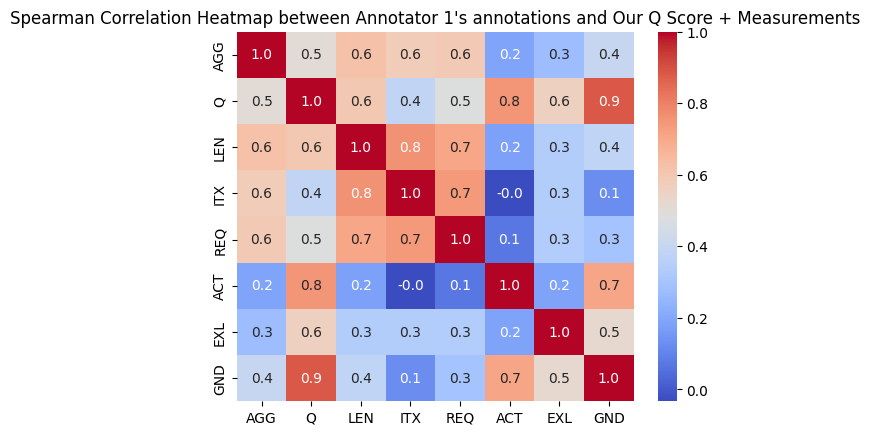

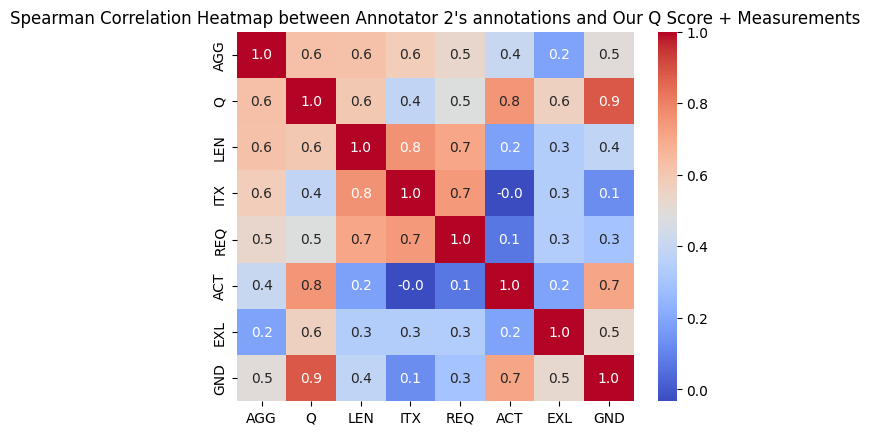

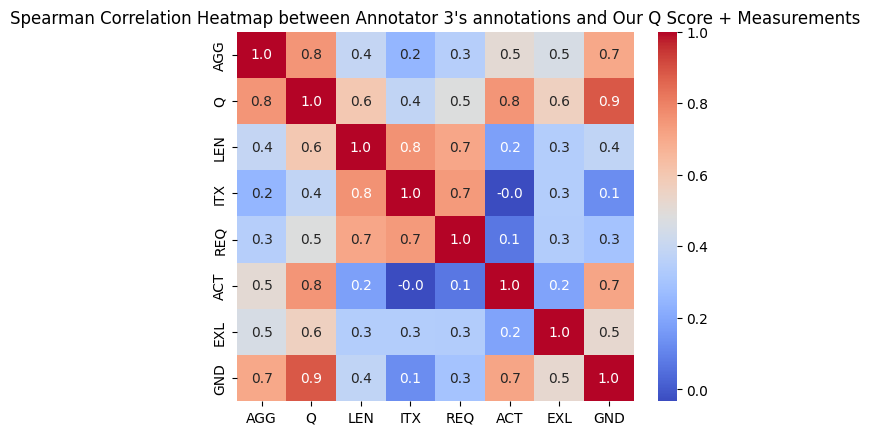

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = pd.DataFrame(aone_scores_for_corr).corr(method='spearman')
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".1f")
plt.title("Spearman Correlation Heatmap between Annotator 1's annotations and Our Q Score + Measurements")
plt.show()

corr = pd.DataFrame(atwo_scores_for_corr).corr(method='spearman')
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".1f")
plt.title("Spearman Correlation Heatmap between Annotator 2's annotations and Our Q Score + Measurements")
plt.show()

corr = pd.DataFrame(athree_scores_for_corr).corr(method='spearman')
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".1f")
plt.title("Spearman Correlation Heatmap between Annotator 3's annotations and Our Q Score + Measurements")
plt.show()

#### Overall correlation

In [24]:
# Select a single score from 3 annotators for each reviewID and combine it with 70 reviews that are singly annotated.
# The score reported in paper is done by varying the random seed 5 times resulting in a Spearman correlation between AGG and Q among 0.56, 0.58, 0.59, 0.60 and 0.61.
sampled_scores = []
random.seed(44)
for i in range(len(aone_refined_df_scores)):
    aone_score = aone_refined_df_scores.iloc[i]
    atwo_score = atwo_refined_df_scores.iloc[i]
    athree_score = athree_refined_df_scores.iloc[i]
    randomly_selected_score = random.choice([aone_score, atwo_score, athree_score])
    sampled_scores.append(randomly_selected_score)

overall_scores = pd.concat([pd.DataFrame(sampled_scores), remaining_df_scores])

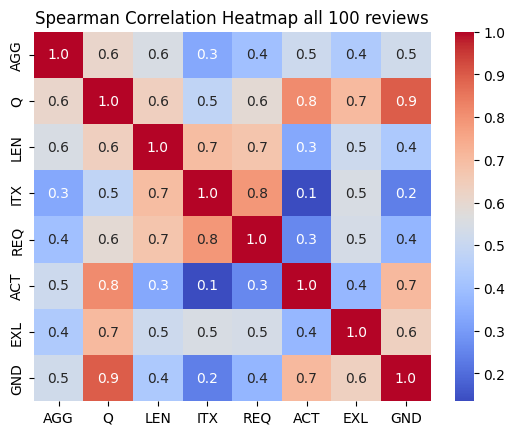

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

overall_scores_for_corr = defaultdict(list)
for review_id in overall_scores['reviewID'].tolist():
    # for aspect in aspects:
    #     overall_scores_for_corr[aspect].append(int(overall_scores[overall_scores['reviewID'] == review_id][aspect].values[0][0]))

    overall_scores_for_corr['AGG'].append(np.mean([int(overall_scores[overall_scores['reviewID'] == review_id][aspect].values[0][0]) for aspect in aspects]))

    # Add our own metrics
    overall_scores_for_corr['Q'].append(rottenreviews_our_automatic_metrics[review_id]['metrics']['Q'])
    for our_metric in ["LEN", "ITX", "REQ", "ACT", "EXL", "GND"]:
        overall_scores_for_corr[our_metric].append(rottenreviews_our_automatic_metrics[review_id]['metrics'][our_metric])

corr = pd.DataFrame(overall_scores_for_corr).corr(method='spearman')
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".1f")
plt.title("Spearman Correlation Heatmap all 100 reviews")
plt.show()